# Regression Analysis

The focus on this page is to analyze the linear regression problem in a more rigourous manor from a statistical perspective.

In [198]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import scipy.linalg as scla
import matplotlib.pyplot as plt



## For R-like Regression Analysis
import statsmodels.api as sm

In [199]:
# Useful function for coordinate descent for Lasso
def S_func(z, alpha):
    s = np.sign(z)*np.max([0.0, np.abs(z) - alpha])
    return s

In [200]:
## Writing my own least squares model ##
def llsq(A, y, alpha = None, alphas = None, Reg = None, CV = False, max_iter = 10000):
    ## Inputs ##
    # A: Data Matix, y: Output/P.O.I, alpha/(s): regularization constant/(s)
    # Reg: Regularization method, CV: Cross validation
    ############

    # Basic shape check
    if A.shape[0] != y.shape[0]:
        raise ValueError(
            f"A and y must have same number of rows (samples); "
            f"got A.shape[0]={A.shape[0]}, y.shape[0]={y.shape[0]}"
        )

    # Check Reg argument
    valid_regs = {None, "Ridge", "Lasso"}
    if Reg not in valid_regs:
        raise ValueError(f"Reg must be one of {valid_regs}, got {Reg!r}")

    # If using CV, alphas must be provided and non-empty
    if CV:
        if alphas is None:
            raise ValueError("CV=True requires `alphas` to be provided.")
        alphas = np.atleast_1d(alphas)
        if alphas.size == 0:
            raise ValueError("`alphas` must be a non-empty 1D array.")

    # If using regularization without CV, alpha must be provided
    if (Reg is not None) and (not CV) and (alpha is None):
        raise ValueError(
            "Regularization is requested (Reg != None) but `alpha` is None "
            "and CV=False. Provide `alpha` or set CV=True with `alphas`."
        )
    
    n_s = A.shape[0]
    n_var = A.shape[1]

    if CV == True:
        n_splits = 5
        kf = KFold(n_splits, shuffle=True, random_state=42)

        i = -1
        score = np.zeros((n_splits, alphas.shape[0]))
        for fold, (train_idx, test_idx) in enumerate(kf.split(A)):
            i += 1
            j = -1
            for a in alphas:
                j += 1
                A_train, A_test = A[train_idx], A[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]
                c_p = llsq(A_train, y_train, alpha = a, Reg = Reg)
                y_test_p = A_test @ c_p
                score[i, j] = r2_score(y_test, y_test_p)
        score = np.mean(score, axis=0)
        alpha = alphas[np.argmax(score)]
        
    
    # Reduced SVD: A = U @ S @ V.T
    U, S, Vh = scla.svd(A, full_matrices = False)
    
    # No Regularization
    if Reg == None:

        # A+ = V @ S^(-1) @ U.T
        x = Vh.T @ np.diag(S**(-1)) @ U.T @ y
    
    # Ridge Regularization
    elif Reg == "Ridge":
        S_pseudo = (S**(2) + alpha)**(-1)*S
        x = Vh.T @ np.diag(S_pseudo) @ U.T @ y

    elif Reg == "Lasso":
        y = y.ravel()
        x = np.zeros(n_var)
        col_norm2 = np.sum(A**2, axis=0)
        for w in range(max_iter):
            x_old = x.copy()
            for k in range(n_var):
                r_k = y - A @ x + A[:, k] * x[k]
                rho_k = A[:, k].dot(r_k)
                x[k] = S_func(rho_k, alpha)/col_norm2[k]
            
            if np.linalg.norm(x - x_old, ord=2) < 1e-7:
                break

    if CV == False:
        return x
    else:
        return x, alpha

## Toy Problem

After too much thought, I decided to generate a test problem for estimating linear parameters. We want no priors on $\alpha$ or $\beta$.

$$
\begin{aligned}
y_i &\sim \text{Normal}(\mu_i, \sigma) \\
\mu_i &= \alpha + \beta x_i \\
\alpha &\propto 1 \\
\beta &\propto 1 \\
\sigma &\sim \text{Uniform}(0,20) \\
\end{aligned}
$$

Let us see what our model problem looks like.

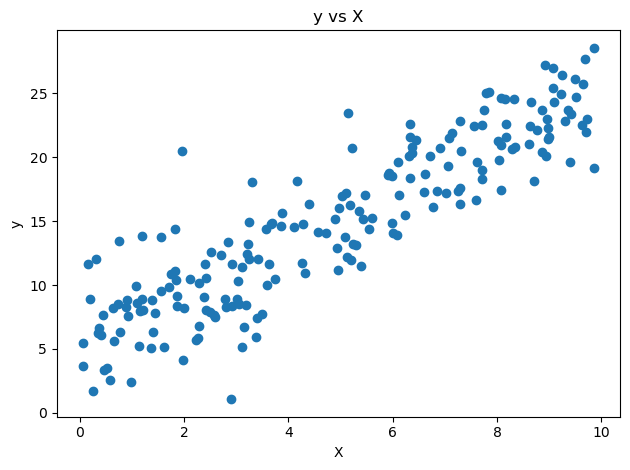

In [201]:
np.random.seed(42)

n = 200

# True parameters
alpha_true = 5.0     # intercept
beta_true  = 2.0     # slope
sigma      = 3.0     # noise std

# Predictor
X = np.random.uniform(0, 10, size=n)

# Response: y = alpha + beta * X + noise
noise = np.random.normal(0, sigma, size=n)
y = alpha_true + beta_true * X + noise

plt.scatter(X, y)
plt.xlabel("X")          # x-axis label
plt.ylabel("y")          # y-axis label
plt.title("y vs X")      # plot title
plt.tight_layout()
plt.show()

## Classical OLS without priors

We will express the minimization problem in the minimum residual form. Let us say we collect measurements $\hat{y}$, where measurements have a linear relationship with some state variables $x$. We describe the relationship as

$$ 
\hat{y} = H x + v,
$$

where $v$ is noise, with mean zero and distributed normally. We can express our estimate for $x$, $\hat{x}$, as

$$
\hat{x} = M\hat{y} + n
$$

We want to minimize the function

$$
J_i = \frac{1}{2} \text{E}[(\hat{x}_i - x_i)^2]
$$

to minimize variance. Say we have perfect estimates $y$. Then we have ${y} = H x$, or $v = 0$.  Then we have $x = MHx + n$. We can impose seemingly natural constraints

$$
\begin{aligned}
n &= 0 \\
MH &= I \\
H^T M^T &= I \\
\end{aligned}
$$

so that 

$$
\hat{x} = M\hat{y}.
$$

If we solve the minimization problem for $J_i$, we eventually arrive at 

$$
M = (H^T R^{-1} H)^{-1} H^T R^{-1},
$$

where $R = \text{cov}({v})$. If all measurements have equal covariance (and in our case we only have one measurement), we arrive at the traditional least squares format

$$
M = (H^T H)^{-1} H^T,
$$

### Centering and Standardization
As a note, I am standardizing and centering data. That is, I am performing the operation

$$
x_{std/cen} = \frac{x - \bar{x}}{\sigma_x}
$$

and

$$
y_{cen} = {y - \bar{y}}.
$$

This actually substantially changes the original problem statement. We can rewrite it as

$$
\begin{aligned}
(y_{cen})_i &\sim \text{Normal}((\mu_{cen})_i, \sigma) \\
(\mu_{cen})_i &= \beta_{cen} (x_{std/cen})_i \\
\beta_{cen} &\propto 1 \\
\sigma &\sim \text{Uniform}(0,20) \\
\end{aligned}
$$

There are easy conversions from this problem statement to the original problem statement. The only major difference is that we are only solving for a single parameter, $\beta$. We need only use the conversion

$$
\mu_i = (\mu_{cen})_i\sigma_x + \bar{y}
$$

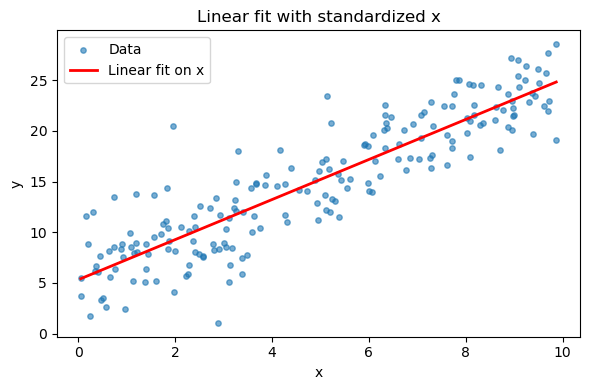

beta (standardized x) = 5.814170992955552


In [202]:
# Standardize/center x
X_mean = np.mean(X)
X_std = np.std(X)
X_stand_cent = ((X - X_mean)/X_std).reshape(-1, 1)

# Center y
y_mean = np.mean(y)
y_fit = y - y_mean

# Only solving for one parameter (beta)
beta = llsq(X_stand_cent, y_fit)[0]

# Scatter of original data
plt.figure(figsize=(6, 4))
plt.scatter(X, y, s=15, alpha=0.6, label="Data")

# Regression line in original X units
x_line = np.linspace(X.min(), X.max(), np.shape(y)[0])
x_line_std = (x_line - X_mean) / X_std
y_line = beta * x_line_std + y_mean      # since model is y = beta * X_std (no intercept)

plt.plot(x_line, y_line, color="red", linewidth=2, label="Linear fit on x")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear fit with standardized x")
plt.legend()
plt.tight_layout()
plt.show()
print("beta (standardized x) =", beta)

## Uncertainty in OLS

There are two main questions we would like to ask. 

* What is the uncertainty in our prediction of $\beta$?
* Given a estimation of $\beta$, what uncertainty is there in our prediction of $y$ given an $x$?

**Given a estimation of $\beta$, what uncertainty is there in our prediction of $y$ given an $x$?**

There is a lot of variance in our data. This could be due to measurement error, other variables we do not know about or cannot measure, or some other factor. Regardless, our prediction will not exactly match the data. We want to encode this somehow. Let us first assume we have an estimation of $\beta$, $\hat{beta}$. What variance do we have on any given prediction? We are attempting to find $\sigma^2 = E(MSE)$. Our estimate of $\sigma^2$, $\hat{\sigma}^2$, is

$$
\hat{\sigma}^2 = \frac{\sum_{i = 1}^n(y_i - {\mu}_i)^2}{n - p}
$$

and $p$ is the number of parameters. A benefit (?) of centering/standardization is we have less parameters to solve for.

**What is the uncertainty in our prediction of $\beta$?**

The actual variance in the estimation $\hat{\beta}$ is 

$$
\sigma^2_{\hat{\beta}} = \frac{\sigma^2}{S_{xx}},
$$

where $S_{xx} = \sum_{i=1}^n (x_i - \bar{x})^2$. Then the estimate $\hat{\sigma}^2_{\hat{\beta}}$ is simply

$$
\hat{\sigma}^2_{\hat{\beta}} = \frac{\hat{\sigma}^2}{S_{xx}}.
$$


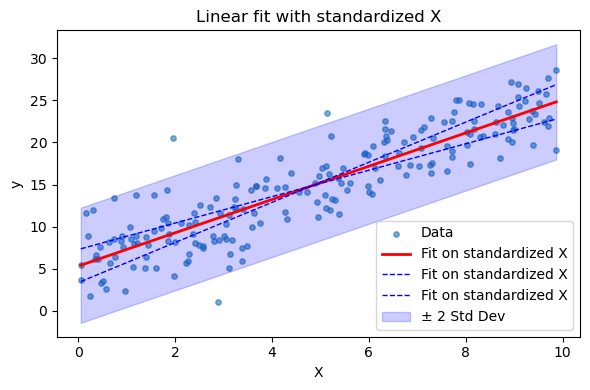

beta (unstandardized X) = 1.9765786795475075


In [203]:
plt.figure(figsize=(6, 4))
plt.scatter(X, y, s=15, alpha=0.6, label="Data")

residuals = y - y_line
sigma2_hat = np.sum(residuals**2)/(np.shape(y)[0] - 1)
Sxx = np.sum(X_stand_cent.flatten()**2)

var_beta = sigma2_hat / Sxx
se_beta = np.sqrt(var_beta)

y_line_plus = (beta + 2*se_beta) * x_line_std   +  y_mean      # since model is y = beta * X_std (no intercept)
y_line_minus = (beta - 2*se_beta) * x_line_std  +  y_mean      # since model is y = beta * X_std (no intercept)

plt.plot(x_line, y_line, color="red", linewidth=2, label="Fit on standardized X")

plt.plot(x_line, y_line_plus, color="blue", linestyle = 'dashed', linewidth=1, label="Fit on standardized X")
plt.plot(x_line, y_line_minus, color="blue", linestyle = 'dashed',linewidth=1, label="Fit on standardized X")

y_se = np.sqrt(sigma2_hat)
y_error = 2*se

plt.fill_between(x_line, y_line - y_error, y_line+ y_error, color='blue', alpha=0.2, label='± 2 Std Dev')

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear fit with standardized X")
plt.legend()
plt.tight_layout()
plt.show()

print("beta (unstandardized X) =", beta/X_std)

## Prior estimates

What if we have some prior information that informs our estimation $\hat{\beta}$?

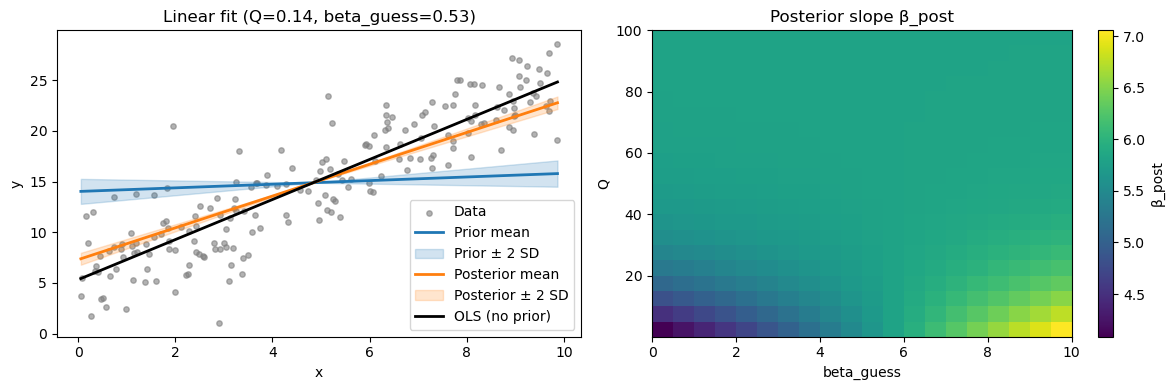

beta_ols (standardized x)   = 5.814170992955552
beta_post (standardized x)  = [[4.61401076]]


In [204]:
# Options for prior variance Q and prior mean beta_guess
Q_options = np.logspace(-1, 2, 20)            # e.g. [0.1, 1, 100]
beta_guess_options = np.linspace(0, 10, 20)   # e.g. [0, 3.33, 6.67, 10]

# Data & standardized x
X_mean = X.mean()
X_std  = X.std()
X_stand_cent = ((X - X_mean) / X_std).reshape(-1, 1)

y_mean = y.mean()
y_cent = y - y_mean

# OLS fit on standardized x for reference
beta_ols = llsq(X_stand_cent, y_cent)[0]
y_fit   = beta_ols * X_stand_cent.flatten() + y_mean

# Residual variance (one parameter beta in centered/std model)
residuals = y - y_fit
n = len(y)
sigma2_hat = np.sum(residuals**2) / (n - 1)

# Precompute scalar XtX, Xty
XtX = X_stand_cent.T @ X_stand_cent        # scalar
Xty = X_stand_cent.T @ y_cent                # scalar

# Grid of posterior slopes
beta_post_grid = np.zeros((len(Q_options), len(beta_guess_options)))
for i, Q in enumerate(Q_options):
    for j, beta_guess in enumerate(beta_guess_options):
        Lambda_post = XtX / sigma2_hat + 1.0 / Q         # posterior precision
        beta_post   = (Xty / sigma2_hat + beta_guess / Q) / Lambda_post
        beta_post_grid[i, j] = beta_post[0][0]                 # scalar


# ---- Choose one Q, beta_guess for the line plots ----
Q = Q_options[1]                    # e.g. middle Q
beta_guess = beta_guess_options[1]  # pick any

Lambda_post = XtX / sigma2_hat + 1.0 / Q
beta_init   = (Xty / sigma2_hat + beta_guess / Q) / Lambda_post

# Prior line and band
x_line      = np.linspace(X.min(), X.max(), 100)
x_line_std  = (x_line - X_mean) / X_std
y_line_guess      = beta_guess * x_line_std + y_mean
y_line_guess_plus = (beta_guess + 2 * np.sqrt(Q)) * x_line_std + y_mean
y_line_guess_minus= (beta_guess - 2 * np.sqrt(Q)) * x_line_std + y_mean

# Posterior line
y_line_init = beta_init * x_line_std + y_mean

y_line_init_plus = (beta_init + 2 / np.sqrt(Lambda_post)) * x_line_std + y_mean
y_line_init_minus = (beta_init - 2 / np.sqrt(Lambda_post)) * x_line_std + y_mean

# OLS line (no prior)
y_line_ols = beta_ols * x_line_std + y_mean

# ---- Subplots ----
fig, (ax_line, ax_heat) = plt.subplots(1, 2, figsize=(12, 4))

# Left: data + prior + posterior + OLS
ax_line.scatter(X, y, s=15, alpha=0.6, color="gray", label="Data")
ax_line.plot(x_line, y_line_guess, color="C0", linewidth=2, label="Prior mean")
ax_line.fill_between(x_line, y_line_guess_minus, y_line_guess_plus,
                     color="C0", alpha=0.2, label="Prior ± 2 SD")
ax_line.plot(x_line, y_line_init.flatten(), color="C1", linewidth=2, label="Posterior mean")
ax_line.fill_between(x_line, y_line_init_minus.flatten(), y_line_init_plus.flatten(), color="C1", alpha=0.2, label="Posterior ± 2 SD")
ax_line.plot(x_line, y_line_ols, color="black", linewidth=2, label="OLS (no prior)")

ax_line.set_xlabel("x")
ax_line.set_ylabel("y")
ax_line.set_title(f"Linear fit (Q={Q:.2g}, beta_guess={beta_guess:.2g})")
ax_line.legend()

# Right: heatmap of posterior slopes over Q, beta_guess
im = ax_heat.imshow(beta_post_grid,
                    origin="lower",
                    aspect="auto",
                    extent=[beta_guess_options[0], beta_guess_options[-1],
                            Q_options[0], Q_options[-1]])

ax_heat.set_xlabel("beta_guess")
ax_heat.set_ylabel("Q")
ax_heat.set_title("Posterior slope β_post")
fig.colorbar(im, ax=ax_heat, label="β_post")

plt.tight_layout()
plt.show()

print("beta_ols (standardized x)   =", beta_ols)
print("beta_post (standardized x)  =", beta_init)